In [1]:
import torch
import numpy as np

import torchvision.models as models
from torchvision.models import ResNet50_Weights
import torch.nn.functional as F


from rise.rise import RISE
from rise.brise import B_RISE
import rise.utils as utils
from rise.utils import IMAGES

from scipy.integrate import trapezoid

import matplotlib.pyplot as plt


# Evaluation

In [11]:
def auc(arr):
    return trapezoid(arr) / (len(arr) - 1)

def zero_substrate(x):
    return torch.zeros_like(x)

def blur_substrate(x):
    return F.avg_pool2d(x, kernel_size=11, stride=1, padding=5)

def causal_metric_single(model,
                         image,
                         saliency,
                         mode="del",
                         step=100,
                         progress_image_count=0,
                         substrate_fn=zero_substrate):

    assert mode in ["del", "ins"]

    device = next(model.parameters()).device
    image = image.to(device)

    # Get target class (original prediction)
    with torch.no_grad():
        pred = model(image)
        target_class = pred.argmax(dim=1).item()

    H, W = saliency.shape
    HW = H * W

    # Flatten saliency
    flat_sal = saliency.flatten()

    # Sort descending (RAW values, no abs)
    order = np.argsort(-flat_sal)

    # Number of steps
    n_steps = (HW + step - 1) // step

    # Setup insertion / deletion
    if mode == "del":
        start = image.clone()
        finish = substrate_fn(image)
    else:
        start = substrate_fn(image)
        finish = image.clone()

    scores = [] 
    C = start.shape[1]

    for i in range(n_steps + 1):

        # Evaluate
        with torch.no_grad():
            pred = model(start)
            prob = torch.softmax(pred, dim=1)[0, target_class].item()
        scores.append(prob)

        if progress_image_count > 0:
            interval = max(1, n_steps // progress_image_count)

            if i in [s for s in range(0, n_steps + 1, interval)]:  # visualize start, middle, end
                img_vis = start[0].detach().cpu()

                # Undo normalization for display (ImageNet)
                if C == 3:
                    # ImageNet unnormalize
                    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
                    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
                    img_vis = img_vis * std + mean
                    img_vis = img_vis.clamp(0,1)
                    plt.imshow(img_vis.permute(1,2,0))

                elif C == 1:
                    # MNIST
                    plt.imshow(img_vis[0], cmap="gray")

                plt.title(f"Step {i}")
                plt.axis("off")
                plt.show()
        
        if i == n_steps:
            break
        
        # Pixels to modify this step
        coords = order[i*step:(i+1)*step]

        # Convert tensor to numpy view
        
        start_np = start.cpu().numpy().reshape(1, C, HW)
        finish_np = finish.cpu().numpy().reshape(1, C, HW)

        # Replace pixels
        start_np[0, :, coords] = finish_np[0, :, coords]

        # Move back to tensor
        start = torch.from_numpy(start_np.reshape(1, C, H, W)).to(device)

    scores = np.array(scores)
    return scores, auc(scores)

# RESNET

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

In [4]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

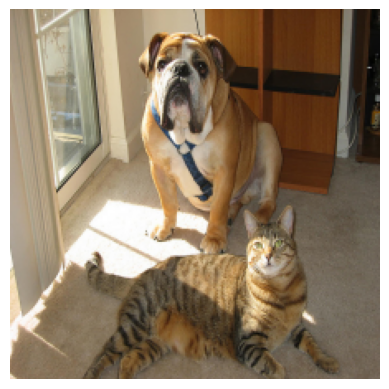

In [5]:
utils.draw_image(img)

## RISE

In [6]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=7, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 3301.02it/s]


In [7]:
sal = rise(img_x)

Running model: 100%|██████████| 50/50 [00:05<00:00,  8.50it/s]


In [8]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)
topk

[{'class_id': 243, 'class_name': 'bull mastiff', 'logit': 6.158624649047852},
 {'class_id': 281, 'class_name': 'tabby', 'logit': 3.580155611038208},
 {'class_id': 242, 'class_name': 'boxer', 'logit': 3.4773542881011963},
 {'class_id': 180,
  'class_name': 'American Staffordshire terrier',
  'logit': 3.3361282348632812},
 {'class_id': 282, 'class_name': 'tiger cat', 'logit': 3.3233225345611572}]

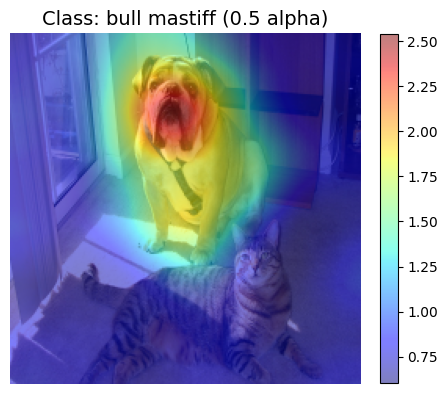

In [9]:
sal_map1 = utils.draw_saliency_overlay(img, sal, topk, k=0, norm_mode="minmax", alpha=0.5)

In [16]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map1,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.013108674690393597


In [17]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map1,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.3983844394952827


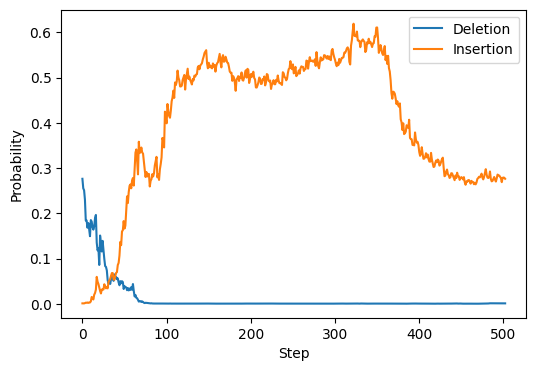

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(scores_del, label="Deletion")
plt.plot(scores_ins, label="Insertion")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.show()

In [19]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.2764473557472229
Final deletion prob: 0.0013994057662785053
Initial insertion prob: 0.0013994057662785053
Final insertion prob: 0.2764473557472229


## B RISE

In [20]:
rise_banzhaf = B_RISE(model, img_x)

In [27]:
rise_banzhaf.generate_masks(100, 7, p = 0.5)

In [28]:
sal = rise_banzhaf.forward(img_x, K = 20)

Estimated forward passes: 2100


Banzhaf sampling: 100%|██████████| 100/100 [00:10<00:00,  9.53it/s]

Total forward passes: 2088


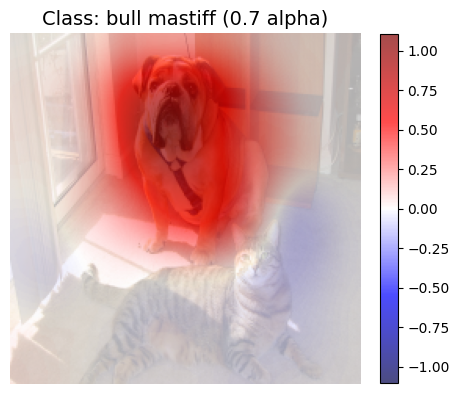

In [29]:
sal_map_brise = utils.draw_saliency_overlay(img, sal, topk, k=0, norm_mode="symmetric", alpha=0.7)

In [30]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.012991608239583247


In [31]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.3888505054674894


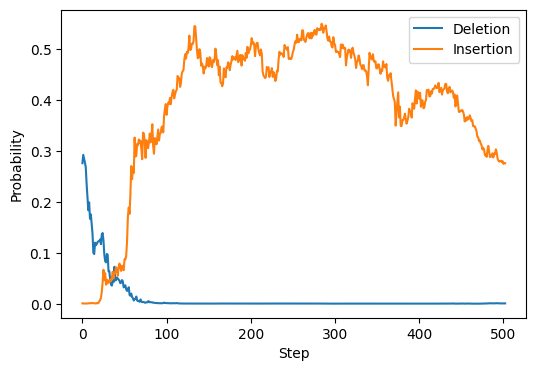

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(scores_del, label="Deletion")
plt.plot(scores_ins, label="Insertion")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.show()

### Goldfsih

In [33]:
img_path = IMAGES / "goldfish.jpg"
img, img_x = utils.load_image(img_path, device, preprocess)

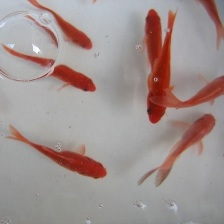

In [34]:
img

#### RISE

In [35]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=9, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 2759.20it/s]


In [36]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 50/50 [00:06<00:00,  8.20it/s]


In [37]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

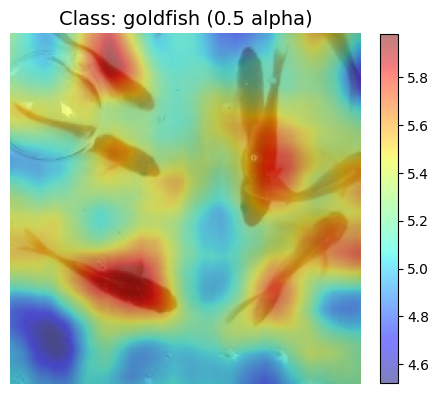

In [38]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=0, norm_mode="minmax", alpha=0.5)

In [47]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.21125587054428113


In [48]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.3353463573774612


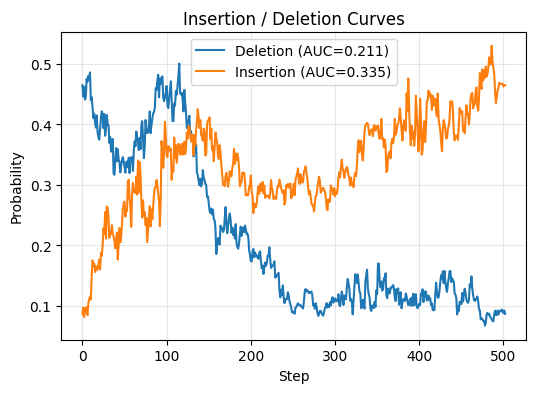

In [52]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

#### BRISE

In [51]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(2000, 10, 0.1)
sal_banzhaf = rise_banzhaf.forward(img_x, K=5)

Estimated forward passes: 12000


Banzhaf sampling: 100%|██████████| 2000/2000 [01:04<00:00, 31.11it/s]

Total forward passes: 12000


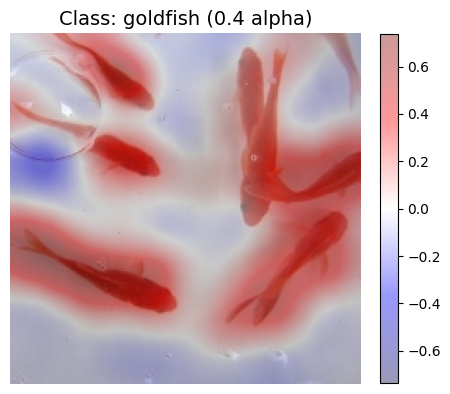

In [54]:
sal_map_brise = utils.draw_saliency_overlay(img, sal_banzhaf, topk, k=0, norm_mode="symmetric", alpha=0.4)

In [55]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.1717684908632738


In [56]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=blur_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.39381540766304945


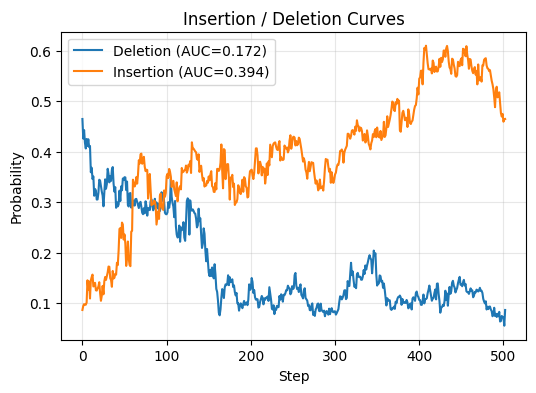

In [57]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

# MNSIT

## Load Data and Train Model

In [58]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [60]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)      # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)      # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [61]:
model = MNISTCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2550
Epoch 2, Loss: 0.0635
Epoch 3, Loss: 0.0427


In [62]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.984


## Get IMAGES

In [63]:
def build_digit_example_dict(model, loader, device, max_samples=100):
    model.eval()

    digit_dict = {d: [] for d in range(10)}
    seen = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(len(x)):
                seen += 1
                digit = y[i].item()

                if preds[i] == y[i]:  # only correct predictions
                    digit_dict[digit].append((x[i:i+1], y[i:i+1]))

                if seen >= max_samples:
                    break

            if seen >= max_samples:
                break

    return digit_dict

In [64]:
examples = build_digit_example_dict(model, test_loader, device)

## Digit 5

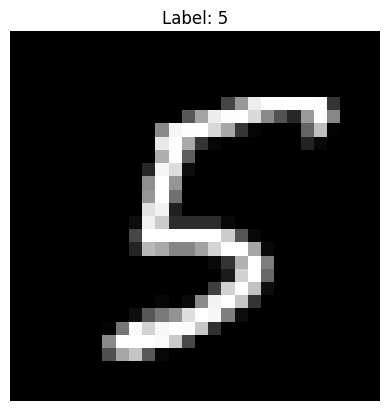

In [ ]:
img_x, label = examples[5][2]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

### B RISE

In [66]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [67]:
sal = rise_banzhaf.forward(img_x, K=10)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 564.80it/s]

Total forward passes: 11000


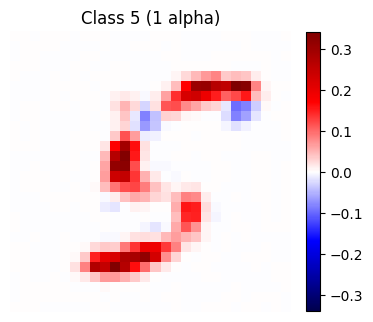

In [68]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5, norm_mode="symmetric", alpha = 1)

In [75]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.19536220468580723


In [76]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9444886334240437


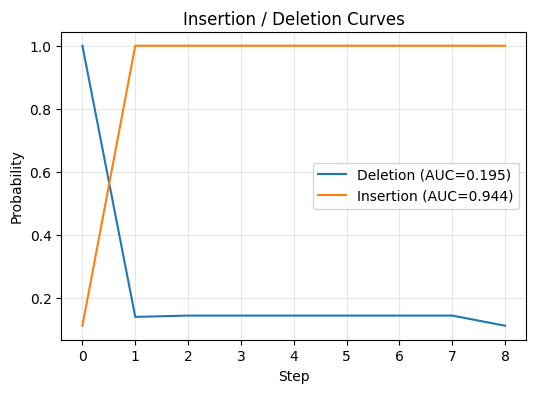

In [77]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.2764473557472229
Final deletion prob: 0.0013994057662785053
Initial insertion prob: 0.0013994057662785053
Final insertion prob: 0.2764473557472229


### RISE

In [78]:
rise = RISE(model, img_x)
rise.generate_masks(N=7000, s=28, p=0.1)

Generating filters: 100%|██████████| 7000/7000 [00:00<00:00, 10674.60it/s]


In [79]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 70/70 [00:00<00:00, 248.93it/s]


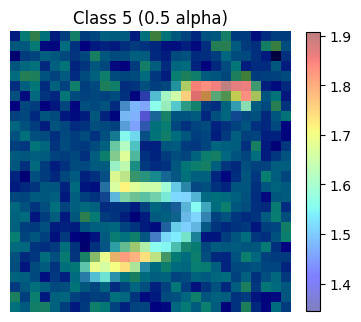

In [80]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=5, norm_mode="minmax", alpha = 0.5)

In [81]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="del",
    step=100,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.14898732746951282


In [82]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="ins",
    step=100,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9443880207836628


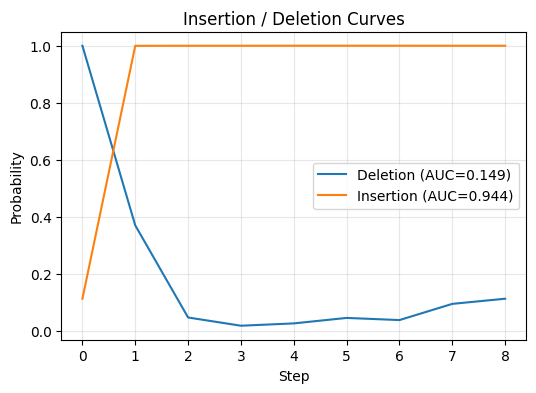

In [83]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [84]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.9998378753662109
Final deletion prob: 0.11228448152542114
Initial insertion prob: 0.11228448152542114
Final insertion prob: 0.9998378753662109


## Digit 8

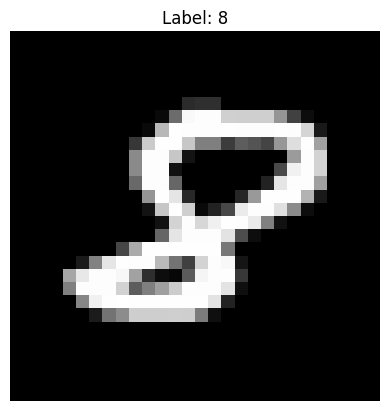

In [133]:
img_x, label = examples[8][0]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

### B RISE

In [86]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [87]:
sal = rise_banzhaf.forward(img_x, K=10)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 568.35it/s]

Total forward passes: 11000


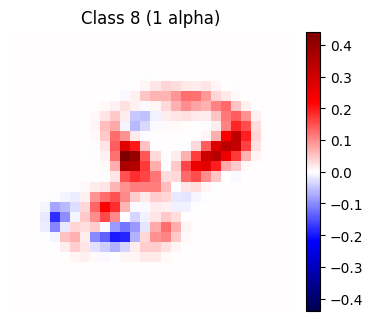

In [107]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=8, norm_mode="symmetric", alpha = 1)

In [122]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.02530044910351888


In [123]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9707166105746083


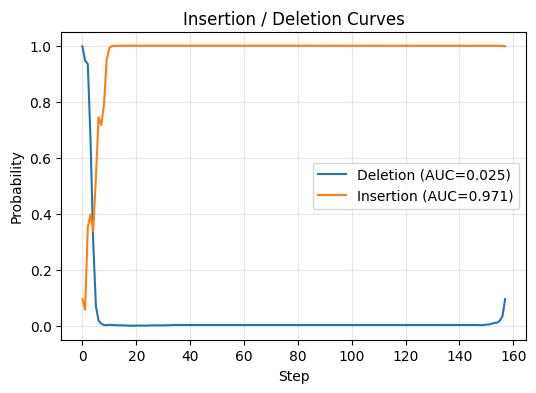

In [124]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [111]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.9977918863296509
Final deletion prob: 0.09551168978214264
Initial insertion prob: 0.09551168978214264
Final insertion prob: 0.9977918863296509


### RISE

In [97]:
rise = RISE(model, img_x)
rise.generate_masks(N=7000, s=28, p=0.1)

Generating filters: 100%|██████████| 7000/7000 [00:00<00:00, 12464.12it/s]


In [98]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 70/70 [00:00<00:00, 812.05it/s]


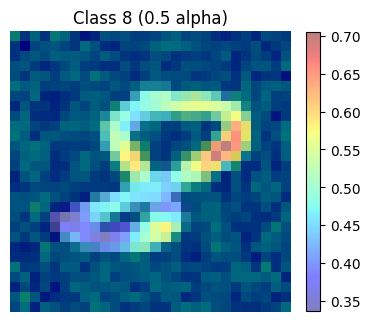

In [112]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=8, norm_mode="minmax", alpha = 0.5)

In [125]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="del",
    step= 5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.029421871505784476


In [126]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9836765953404888


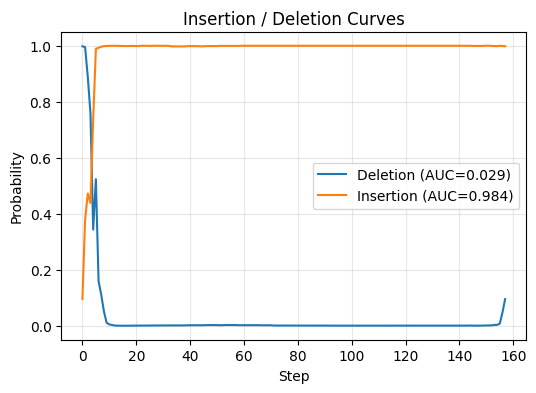

In [127]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.9998378753662109
Final deletion prob: 0.11228448152542114
Initial insertion prob: 0.11228448152542114
Final insertion prob: 0.9998378753662109


## Digit 4

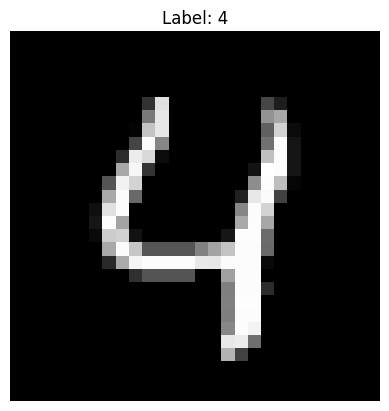

In [134]:
img_x, label = examples[4][0]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

### B RISE

In [135]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5)

In [136]:
sal = rise_banzhaf.forward(img_x, K=10)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 583.22it/s]

Total forward passes: 11000


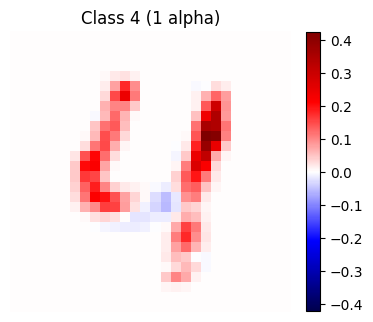

In [137]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=4, norm_mode="symmetric", alpha = 1)

In [138]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.03293435063263532


In [139]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9782877553989933


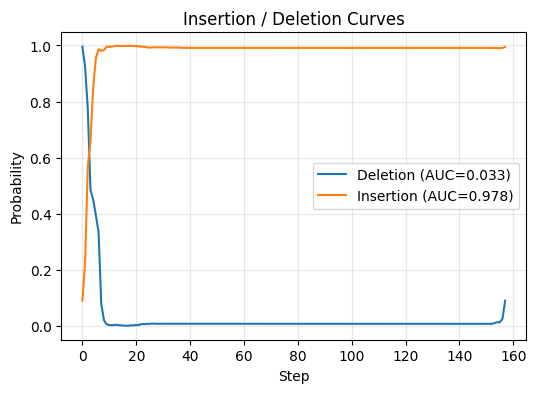

In [140]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [141]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.9952025413513184
Final deletion prob: 0.0905589759349823
Initial insertion prob: 0.0905589759349823
Final insertion prob: 0.9952025413513184


### RISE

In [163]:
rise = RISE(model, img_x)
rise.generate_masks(N=14000, s=28, p=0.1)

Generating filters: 100%|██████████| 14000/14000 [00:01<00:00, 12616.46it/s]


In [164]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 140/140 [00:00<00:00, 366.27it/s]


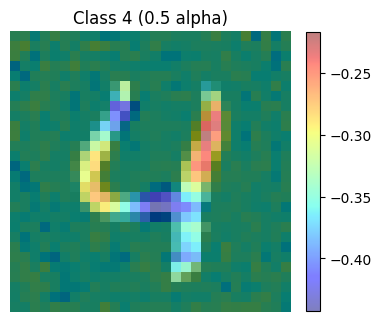

In [165]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=4, norm_mode="minmax", alpha = 0.5)

In [166]:
scores_del, auc_del = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="del",
    step= 5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.054203360191706546


In [167]:
scores_ins, auc_ins = causal_metric_single(
    model,
    img_x,
    sal_map_rise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9758364999560034


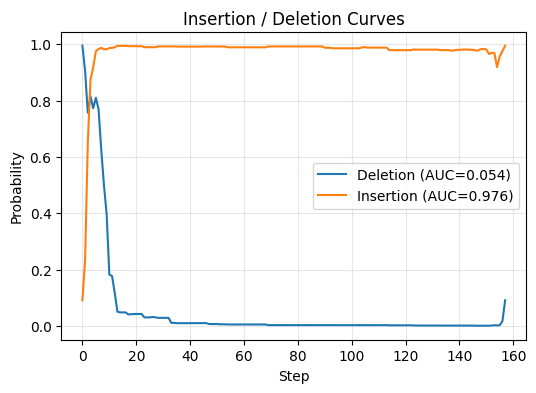

In [168]:
plt.figure(figsize=(6,4))

plt.plot(scores_del, label=f"Deletion (AUC={auc_del:.3f})")
plt.plot(scores_ins, label=f"Insertion (AUC={auc_ins:.3f})")

plt.legend()
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Insertion / Deletion Curves")
plt.grid(alpha=0.3)

plt.show()

In [169]:
print("Initial prob:", scores_del[0])
print("Final deletion prob:", scores_del[-1])
print("Initial insertion prob:", scores_ins[0])
print("Final insertion prob:", scores_ins[-1])

Initial prob: 0.9952025413513184
Final deletion prob: 0.0905589759349823
Initial insertion prob: 0.0905589759349823
Final insertion prob: 0.9952025413513184
